# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name_: Joaquin A. Castaneda
- _Student No._: 2024-09743
- _Section_: THR-TX1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

![Convergence of Numerical Root-Finding Methods](convergence.png)

Figure 1. Convergence of Numerical Root-Finding Methods


### Report discussion

The figure plots each method's estimate xᵢ against the iteration number (which is i), with a dotted line which marks the true root, so a method has converged when its markers settle on that line. In Region 1 (x ≈ -1.1927), Newton converges fastest. Bisection moves steadily, and secant overshoots early before settling. In Region 2, the double root at x = 2, bisection fails because f touches zero without changing sign, so no bracket exists. Newton slows to linear convergence because the derivative is zero at a double root, secant is erratic, and fixed-point approaches toward 2 gradually until it hits the 100-iteration limit. In Region 3 (x ≈ 4.5959), Newton converges fastest, followed by secant, whereas, fixed-point approaches slowly from below. Overall, Newton is fastest when the derivative is nonzero at the root, secant is similar but can overshoot, bisection is slow but reliable when a sign change exists, and fixed-point is slowest.

- Bisection Method: It is reliable/guaranteed to converge if the function is continuous and also if the interval has a sign change. However, it converges slowly and can't find roots where function does not change sign (like the double root at x = 2).
- Fixed-Point Iteration: It's simple to implement and only requires a rearranged form of the function. However, convergence depends on chosen rearrangement and initial guess (so it may diverge or converge to a different root).
- Newton's Method: It usually converges fast when initial guess is close to a simple root. However, it requires the derivative and can fail if the derivative is zero or the initial guess is unsuitable. (It may also converge slow for multiple roots).
- Secant Method: It usually converges faster than bisection and it also does not require the derivative. However, it is less reliable because convergence depends on the initial guesses (also it can fail when consecutive function values are too similar).


### Reflection

Sometimes there are many ways of doing the same thing. It's a matter of discovering what works for us and what doesn't. 

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately.
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

In [13]:
import math
import matplotlib.pyplot as plt
import numpy as np

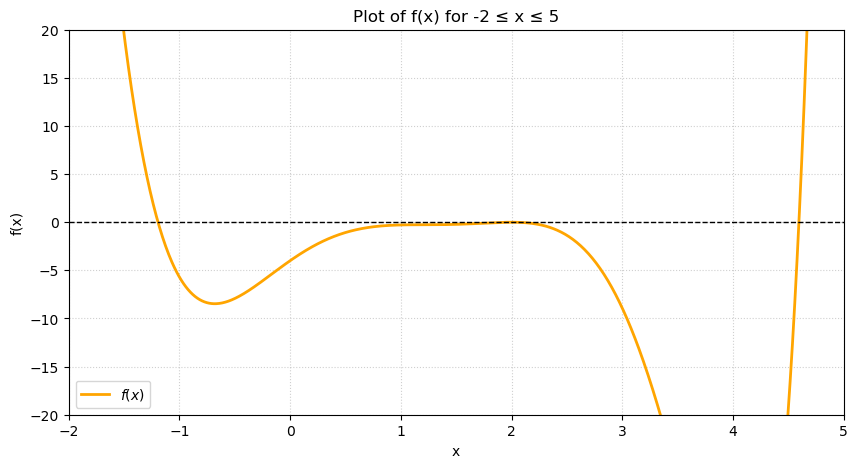

In [14]:
# f(x)
def f(x):
    return -x**5 + 4*x**4 - 4*x**3 + (x**2)*math.exp(x) - 2*x**2 - 4*x*math.exp(x) + 8*x + 4*math.exp(x) - 8

# f'(x)
def df(x):
    return -5*x**4 + 16*x**3 - 12*x**2 - 4*x + 8 + (x**2 - 2*x)*math.exp(x)

# Fixed-Point Iteration Functions g(x)

def g_isolate_8x(x):
    return (x**5 - 4*x**4 + 4*x**3 - (x**2)*math.exp(x) + 2*x**2 + 4*x*math.exp(x) - 4*math.exp(x) + 8) / 8

def g_isolate_exp(x):
    numerator = x**5 - 4*x**4 + 4*x**3 + 2*x**2 - 8*x + 8
    denominator = (x - 2)**2
    val = numerator / denominator if denominator != 0 else 1e-12
    return math.log(val) if val > 0 else 0


# Make grid from -2 to 5
x_vals = np.linspace(-2, 5, 1000)
y_vals = np.array([f(x) for x in x_vals])

# Plot

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label=r"$f(x)$", color="orange", linewidth=2)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.ylim(-20, 20)
plt.xlim(-2, 5)
plt.title("Plot of f(x) for -2 ≤ x ≤ 5")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.savefig("7plot.png")
plt.show()

In [18]:
def fixed_point(g, initial_guess, tolerance=1e-6, max_iterations=100):
    estimates = [initial_guess]
    current = initial_guess

    for iteration in range(max_iterations):
        next_estimate = g(current) # Calculate next estimate
        estimates.append(next_estimate)

        if abs(next_estimate - current) < tolerance: # Check convergence
            break

        current = next_estimate # Update current estimate

    return estimates[-1], estimates # Return final estimate at yung history

In [33]:
def bisection(f, lower_bound, upper_bound, tolerance=1e-6, max_iterations=100):
    estimates = []
    f_lower, f_upper = f(lower_bound), f(upper_bound) # Evaluate endpoints

    if f_lower * f_upper >= 0: # Check for sign change
        print(f"Bisection failed on [{lower_bound}, {upper_bound}] since there's no sign change.")
        return None, estimates # Return failure and empty history

    for iteration in range(max_iterations):
        midpoint = (lower_bound + upper_bound) / 2.0 # Calculate midpoint
        estimates.append(midpoint)
        f_mid = f(midpoint) # Evaluate function at midpoint

        if abs(f_mid) < tolerance or (upper_bound - lower_bound) / 2.0 < tolerance:
            break # Stop if close to root

        if f_mid * f_lower < 0: # Root sa left half
            upper_bound, f_upper = midpoint, f_mid
        else: # Root sa right half
            lower_bound, f_lower = midpoint, f_mid

    return estimates[-1], estimates # Return final estimate at history

In [34]:
def newton(f, df, initial_guess, tolerance=1e-6, max_iterations=100):
    estimates = [initial_guess]
    current = initial_guess

    for iteration in range(max_iterations):
        function_value = f(current) # Eval function
        derivative_value = df(current) # Eval derivative

        if abs(function_value) < tolerance: # Check convergence
            break 

        if derivative_value == 0: # Wag div by zero
            print("Newton-Raphson failed since the derivative = 0")
            break

        current = current - function_value / derivative_value # Update estimate
        estimates.append(current)

    return estimates[-1], estimates # Return final estimate at history

In [29]:
def secant(f, first_guess, second_guess, tolerance=1e-6, max_iterations=100):
    estimates = [first_guess, second_guess]

    for iteration in range(max_iterations):
        previous_value = f(estimates[-2]) # Evaluate previous estimate
        current_value = f(estimates[-1]) # Evaluate current estimate

        if abs(current_value) < tolerance or abs(current_value - previous_value) < 1e-12: # Avoid division by near-zero
            break

        next_estimate = estimates[-1] - current_value * (
            estimates[-1] - estimates[-2]
        ) / (current_value - previous_value) # Calculate next estimate

        estimates.append(next_estimate)

    return estimates[-1], estimates # Return final estimate at history

In [35]:
# Region 1: Interval [-2, 0]
print("--- Region 1 ---")
region1_bisection_root, region1_bisection_history = bisection(
    f, lower_bound=-2.0, upper_bound=0.0
)
region1_newton_root, region1_newton_history = newton(
    f, df, initial_guess=-1.0
)
region1_secant_root, region1_secant_history = secant(
    f, first_guess=-1.5, second_guess=-0.5
)

# Region 2: Interval [1, 3]
print("\n--- Region 2 ---")
region2_bisection_root, region2_bisection_history = bisection(
    f, lower_bound=1.0, upper_bound=3.0
)
region2_fixed_point_root, region2_fixed_point_history = fixed_point(
    g_isolate_8x, initial_guess=1.9
)
region2_newton_root, region2_newton_history = newton(
    f, df, initial_guess=1.5
)
region2_secant_root, region2_secant_history = secant(
    f, first_guess=1.5, second_guess=2.5
)

# Region 3: Interval [4, 5]
print("\n--- Region 3 ---")
region3_bisection_root, region3_bisection_history = bisection(
    f, lower_bound=4.0, upper_bound=5.0
)
region3_fixed_point_root, region3_fixed_point_history = fixed_point(
    g_isolate_exp, initial_guess=4.0
)
region3_newton_root, region3_newton_history = newton(
    f, df, initial_guess=4.8
)
region3_secant_root, region3_secant_history = secant(
    f, first_guess=4.0, second_guess=4.8
)

# Summary of roots
print("\n--- Summary of Discovered Roots ---")
print(f"Region 1 Root: {region1_newton_root:.6f}")
print(f"Region 2 Root: {region2_newton_root:.6f}")
print(f"Region 3 Root: {region3_newton_root:.6f}")

--- Region 1 ---

--- Region 2 ---
Bisection failed on [1.0, 3.0] since there's no sign change.

--- Region 3 ---

--- Summary of Discovered Roots ---
Region 1 Root: -1.192686
Region 2 Root: 2.000480
Region 3 Root: 4.595864


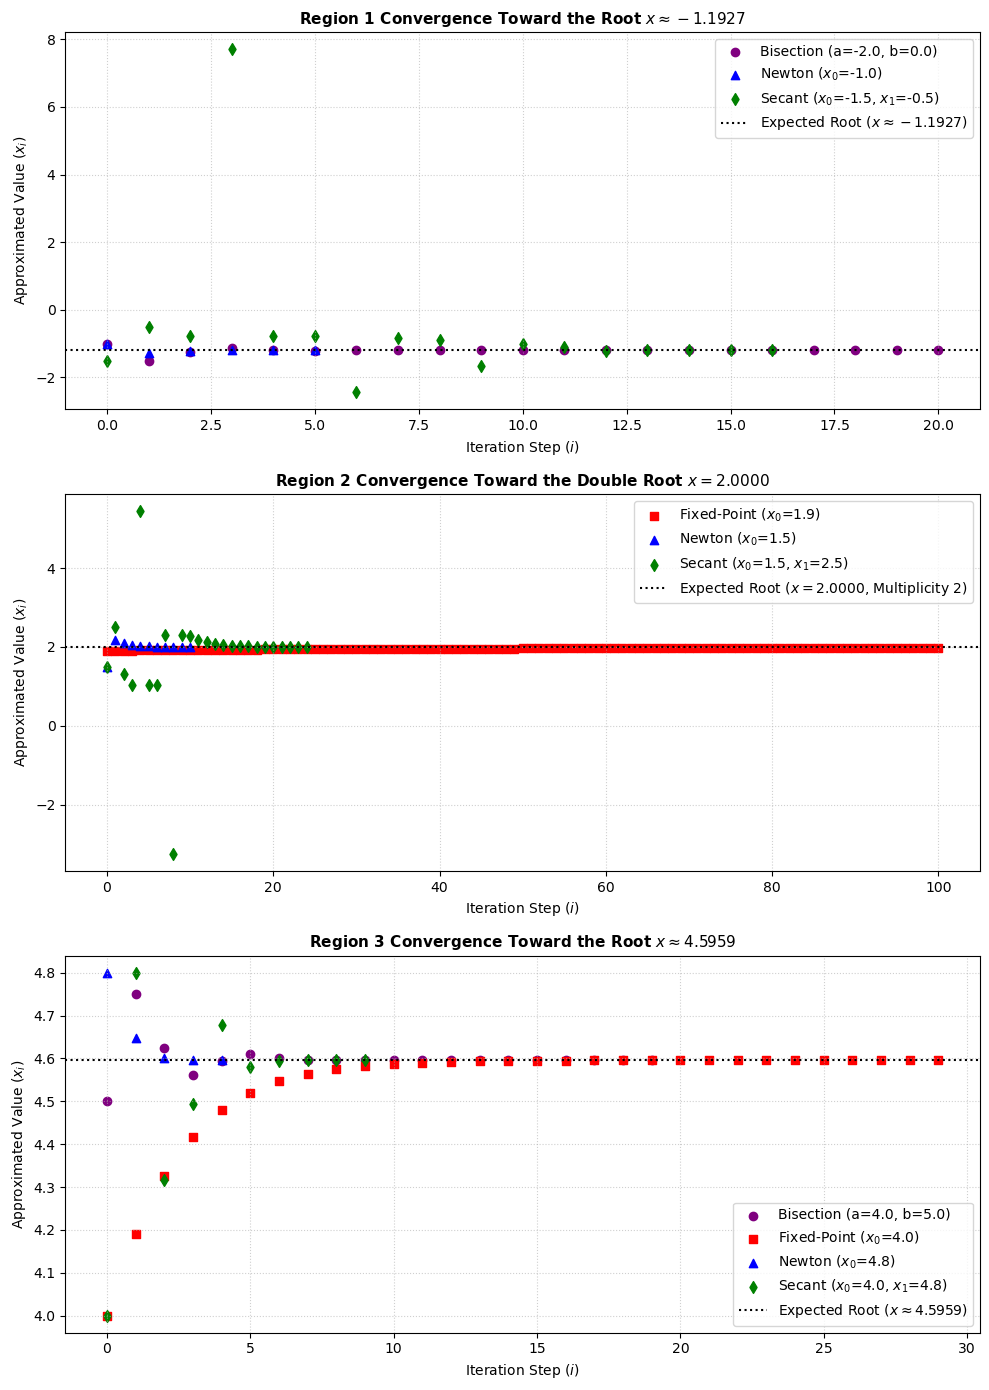

In [43]:
# Scatter plots of convergence
fig, axes = plt.subplots(3, 1, figsize=(10, 14))

# Region 1 Convergence
axes[0].scatter(range(len(region1_bisection_history)), region1_bisection_history,
                label="Bisection (a=-2.0, b=0.0)", color="purple", marker="o")
axes[0].scatter(range(len(region1_newton_history)), region1_newton_history,
                label="Newton ($x_0$=-1.0)", color="blue", marker="^")
axes[0].scatter(range(len(region1_secant_history)), region1_secant_history,
                label="Secant ($x_0$=-1.5, $x_1$=-0.5)", color="green", marker="d")

axes[0].axhline(y=-1.192686, color="black", linestyle=":", linewidth=1.5,
                label="Expected Root ($x \\approx -1.1927$)")
axes[0].set_title(r"Region 1 Convergence Toward the Root $x \approx -1.1927$",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Iteration Step ($i$)")
axes[0].set_ylabel("Approximated Value ($x_i$)")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(loc="upper right")

# Region 2 Convergence
if len(region2_fixed_point_history) > 0:
    axes[1].scatter(range(len(region2_fixed_point_history)), region2_fixed_point_history,
                    label="Fixed-Point ($x_0$=1.9)", color="red", marker="s")

axes[1].scatter(range(len(region2_newton_history)), region2_newton_history,
                label="Newton ($x_0$=1.5)", color="blue", marker="^")
axes[1].scatter(range(len(region2_secant_history)), region2_secant_history,
                label="Secant ($x_0$=1.5, $x_1$=2.5)", color="green", marker="d")

axes[1].axhline(y=2.0, color="black", linestyle=":", linewidth=1.5,
                label="Expected Root ($x = 2.0000$, Multiplicity 2)")
axes[1].set_title(r"Region 2 Convergence Toward the Double Root $x = 2.0000$",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Iteration Step ($i$)")
axes[1].set_ylabel("Approximated Value ($x_i$)")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(loc="upper right")

# Region 3 Convergence
axes[2].scatter(range(len(region3_bisection_history)), region3_bisection_history,
                label="Bisection (a=4.0, b=5.0)", color="purple", marker="o")
axes[2].scatter(range(len(region3_fixed_point_history)), region3_fixed_point_history,
                label="Fixed-Point ($x_0$=4.0)", color="red", marker="s")
axes[2].scatter(range(len(region3_newton_history)), region3_newton_history,
                label="Newton ($x_0$=4.8)", color="blue", marker="^")
axes[2].scatter(range(len(region3_secant_history)), region3_secant_history,
                label="Secant ($x_0$=4.0, $x_1$=4.8)", color="green", marker="d")

axes[2].axhline(y=4.595864, color="black", linestyle=":", linewidth=1.5,
                label="Expected Root ($x \\approx 4.5959$)")
axes[2].set_title(r"Region 3 Convergence Toward the Root $x \approx 4.5959$",
                  fontsize=11, fontweight="bold")
axes[2].set_xlabel("Iteration Step ($i$)")
axes[2].set_ylabel("Approximated Value ($x_i$)")
axes[2].grid(True, linestyle=":", alpha=0.6)
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.savefig("convergence.png")
plt.show()

#### Problem 1 code summary

The entire code above finds the roots of the function using four numerical methods: bisection, fixed-point iteration, Newton's method, and the secant method. Different initial guesses and intervals are used for each region so that we can compare how the methods converge to the roots. The iteration values are stored/plotted to show how each method approaches the expected root. 

**End of Notebook.**